# Exploring the DataPulse Dataset — Generate → Validate → Query

DataPulse ships a **seeded, multi-domain synthetic enterprise dataset** — Sales, IT, HR,
Marketing, and Security — so the natural-language query agent always has realistic,
reproducible data to work against.

This notebook is a guided, **offline** tour of that dataset, following the pipeline end to end:

> **Catalog → Generate → Validate → Load → Query**

Every cell runs against the git-tracked data (`src/data/*.csv`, `src/db/sales.db`) with **no
API keys or network** required. To watch the agent answer questions over this data, open
[`inference_walkthrough.ipynb`](inference_walkthrough.ipynb).

## Setup

Add the repository root to `sys.path` so the `src.*` packages import no matter where the
kernel was started.

In [1]:
import sys, warnings
from pathlib import Path


def _find_root(start: Path) -> Path:
    for cand in [start.resolve(), *start.resolve().parents]:
        if (cand / "pyproject.toml").exists():
            return cand
    return start.resolve()


PROJECT_ROOT = _find_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 70)
print("repo   :", PROJECT_ROOT.name)
print("pandas :", pd.__version__)

repo   : Data_Pulse_New
pandas : 3.0.2


## 1. The Catalog — one contract for everything

`src/metadata/schema.json` is the single source of truth. The same catalog drives
**generation** (what to synthesize), **loading** (the SQLite DDL), **validation** (what to
check), and the **knowledge graph** (the agent's schema context). `metadata.utils` reads it.

In [2]:
from src.metadata.utils import (
    get_all_tables,
    get_categorical_values,
    get_domains,
    get_metrics,
    load_schema,
)

schema  = load_schema()
tables  = get_all_tables(schema)
domains = get_domains(schema)

print(f"schema version           : {schema.get('version')}")
print(f"domains                  : {len(domains)}")
print(f"tables                   : {len(tables)}")
print(f"canonical metrics        : {len(get_metrics(schema))}")
print(f"controlled-vocab columns : {len(get_categorical_values(schema))}")

pd.DataFrame(domains)

schema version           : 2.0
domains                  : 5
tables                   : 50
canonical metrics        : 13
controlled-vocab columns : 62


,name,description
0,Sales,"Sales operations covering customers, products, orders, revenue, ta..."
1,IT,"Information Technology operations covering assets, incidents, proj..."
2,HR,"Human Resources covering employees, payroll, performance, leave, r..."
3,Marketing,"Marketing operations covering campaigns, leads, channels, content,..."
4,Security,"Cybersecurity operations covering users, access control, incidents..."


Business measures are defined **once**, in the catalog's metric glossary. The agent is
instructed to use these exact expressions, so "revenue" always means the same thing
(`order_items.line_total`, never `invoices.amount`):

In [3]:
pd.DataFrame(get_metrics(schema))[["name", "expression"]]

,name,expression
0,total revenue,SUM(order_items.line_total)
1,average order value,SUM(order_items.line_total) / COUNT(DISTINCT order_items.order_id)
2,gross margin,SUM((order_items.unit_price - products.cost_price) * order_items.q...
3,target attainment rate,SUM(sales_targets.achieved_amount) / SUM(sales_targets.target_amount)
4,deployment success rate,100.0 * SUM(CASE WHEN deployments.status = 'Success' THEN 1 ELSE 0...
5,incident MTTR (hours),AVG((JULIANDAY(it_incidents.resolved_at) - JULIANDAY(it_incidents....
6,headcount,COUNT(DISTINCT employees.employee_id)
7,average salary,AVG(payroll.gross_salary)
8,lead conversion rate,100.0 * SUM(CASE WHEN leads.status = 'Converted' THEN 1 ELSE 0 END...
9,email open rate,100.0 * SUM(email_campaigns.open_count) / SUM(email_campaigns.sent...


## 2. The Generated Data — tables, rows, and a peek

The catalog is realized as one CSV per table (git-tracked under `src/data/`) and loaded into
`src/db/sales.db`. Here are the row counts per domain, straight from the database:

In [4]:
import sqlite3

from src.db.loader import DB_PATH

domain_of = {t["name"]: t["domain"] for t in tables}
with sqlite3.connect(f"file:{DB_PATH.as_posix()}?mode=ro", uri=True) as conn:
    counts = {name: conn.execute(f'SELECT COUNT(*) FROM "{name}"').fetchone()[0] for name in domain_of}

manifest = pd.DataFrame({"table": list(counts), "rows": list(counts.values())})
manifest["domain"] = manifest["table"].map(domain_of)

by_domain = (
    manifest.groupby("domain")["rows"]
    .agg(tables="count", rows="sum")
    .sort_values("rows", ascending=False)
)
print(by_domain, "\n")
print(f"total: {by_domain['tables'].sum()} tables, {by_domain['rows'].sum():,} rows")

           tables   rows
domain                  
Sales          10  10087
HR             10   5790
Security       10   3156
Marketing      10   2898
IT             10   1362 

total: 50 tables, 23,293 rows


A peek at the `orders` fact table:

In [5]:
with sqlite3.connect(f"file:{DB_PATH.as_posix()}?mode=ro", uri=True) as conn:
    orders_head = pd.read_sql_query("SELECT * FROM orders LIMIT 5", conn)
orders_head

,order_id,customer_id,rep_id,order_date,status,channel,discount_pct,shipping_cost,region_id
0,1,481,21,2022-06-22,Cancelled,Phone,0.0,22.94,1
1,2,12,3,2023-02-09,Delivered,Online,0.0,22.63,3
2,3,63,2,2024-08-02,Pending,Online,10.0,10.83,4
3,4,255,1,2024-02-23,Delivered,Online,0.0,5.37,2
4,5,141,9,2024-07-02,Processing,Online,10.0,15.48,2


## 3. Reproducibility — seed 42 is byte-identical

Generation is **seeded per run** (an injected `random.Random(seed)` plus a seeded `Faker`), so
any two `generate(seed)` calls produce byte-identical CSVs. The tracked `src/data/*.csv` are
the seed-42 output. Below we regenerate into a **temporary directory** (never touching
`src/data`) and byte-compare every file:

In [6]:
import filecmp
import tempfile

from src.datagen.generate import DATA_DIR, generate

tmp = Path(tempfile.mkdtemp(prefix="datapulse_regen_"))
row_counts = generate(seed=42, data_dir=tmp)  # writes to the temp dir, not src/data
identical = sum(
    1
    for name in row_counts
    if filecmp.cmp(tmp / f"{name}.csv", DATA_DIR / f"{name}.csv", shallow=False)
)
print(f"regenerated {len(row_counts)} tables / {sum(row_counts.values()):,} rows from seed 42")
print(f"byte-identical to committed src/data : {identical}/{len(row_counts)}")

regenerated 50 tables / 23,293 rows from seed 42
byte-identical to committed src/data : 50/50


## 4. Data Quality — conformance & referential integrity

The validator is schema-driven and dependency-light (no scipy). It checks **schema
conformance** (dtypes, nulls, primary-key uniqueness, controlled-vocabulary membership) and
**referential integrity** across the foreign-key graph, and emits a descriptive per-column
**profile**.

In [7]:
from src.quality.validator import validate_dataset

report = validate_dataset(DATA_DIR)
s = report.summary
print(f"overall pass          : {s['pass']}")
print(f"schema conformance    : {s['schema_pass']}")
print(f"referential integrity : {s['referential_integrity_pass']}")
print(f"tables / rows         : {s['table_count']} / {s['total_rows']:,}")
print(f"violations            : {s['violation_count']}")

overall pass          : True
schema conformance    : True
referential integrity : True
tables / rows         : 50 / 23,293
violations            : 0


The profile *describes* each column — it does not grade it, since the generator declares no
expected distributions:

In [8]:
prof = report.profile["orders"]
print(f"orders - {prof['row_count']:,} rows, {prof['column_count']} columns, domain={prof['domain']}\n")
pd.DataFrame(prof["columns"]).T[["type", "role", "nulls", "distinct", "distinct_pct"]]

orders - 2,000 rows, 9 columns, domain=Sales



,type,role,nulls,distinct,distinct_pct
order_id,INTEGER,key,0,2000,100.0
customer_id,INTEGER,reference,0,493,24.6
rep_id,INTEGER,reference,0,30,1.5
order_date,DATE,datetime,0,909,45.5
status,TEXT,categorical,0,5,0.2
channel,TEXT,categorical,0,3,0.1
discount_pct,REAL,numeric,0,5,0.2
shipping_cost,REAL,numeric,0,1358,67.9
region_id,INTEGER,reference,0,5,0.2


## 5. A Couple of Distributions

Because everything is queryable SQL, a chart is one `read_sql_query` away.

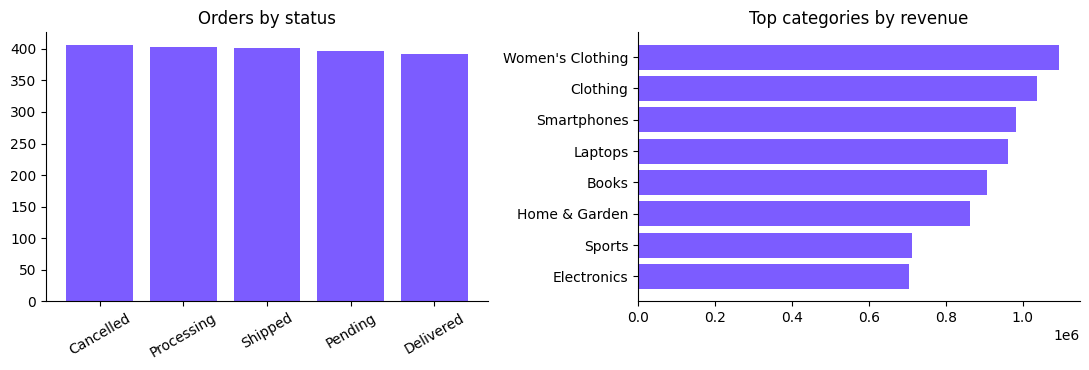

In [9]:
import matplotlib.pyplot as plt

with sqlite3.connect(f"file:{DB_PATH.as_posix()}?mode=ro", uri=True) as conn:
    by_status = pd.read_sql_query(
        "SELECT status, COUNT(*) AS orders FROM orders GROUP BY status ORDER BY orders DESC", conn
    )
    by_cat = pd.read_sql_query(
        '''SELECT c.category_name AS category, ROUND(SUM(oi.line_total), 0) AS revenue
           FROM order_items oi
           JOIN products   p ON oi.product_id  = p.product_id
           JOIN categories c ON p.category_id  = c.category_id
           GROUP BY c.category_name
           ORDER BY revenue DESC
           LIMIT 8''',
        conn,
    )

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.8))
ax1.bar(by_status["status"], by_status["orders"], color="#7c5cff")
ax1.set_title("Orders by status")
ax1.tick_params(axis="x", rotation=30)
ax2.barh(by_cat["category"][::-1], by_cat["revenue"][::-1], color="#7c5cff")
ax2.set_title("Top categories by revenue")
for ax in (ax1, ax2):
    ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()

## Next Steps

- **[`inference_walkthrough.ipynb`](inference_walkthrough.ipynb)** — ask this dataset questions
  in plain English and watch the agent answer.
- Regenerate, reload, and rebuild the knowledge graph end to end:
  `uv run python -m src.pipeline` (or the `/run-pipeline` command).